Model loaded
Found 1610 test images. Running detection...

  Processed 100/1610 images...
  Processed 200/1610 images...
  Processed 300/1610 images...
  Processed 400/1610 images...
  Processed 500/1610 images...
  Processed 600/1610 images...
  Processed 700/1610 images...
  Processed 800/1610 images...
  Processed 900/1610 images...
  Processed 1000/1610 images...
  Processed 1100/1610 images...
  Processed 1200/1610 images...
  Processed 1300/1610 images...
  Processed 1400/1610 images...
  Processed 1500/1610 images...
  Processed 1600/1610 images...

 Detection complete!
   Total images processed : 1610
   Total humans detected  : 10440
   Avg humans per image   : 6.5
   Results saved to       : D:\ANTS\task03_outputs


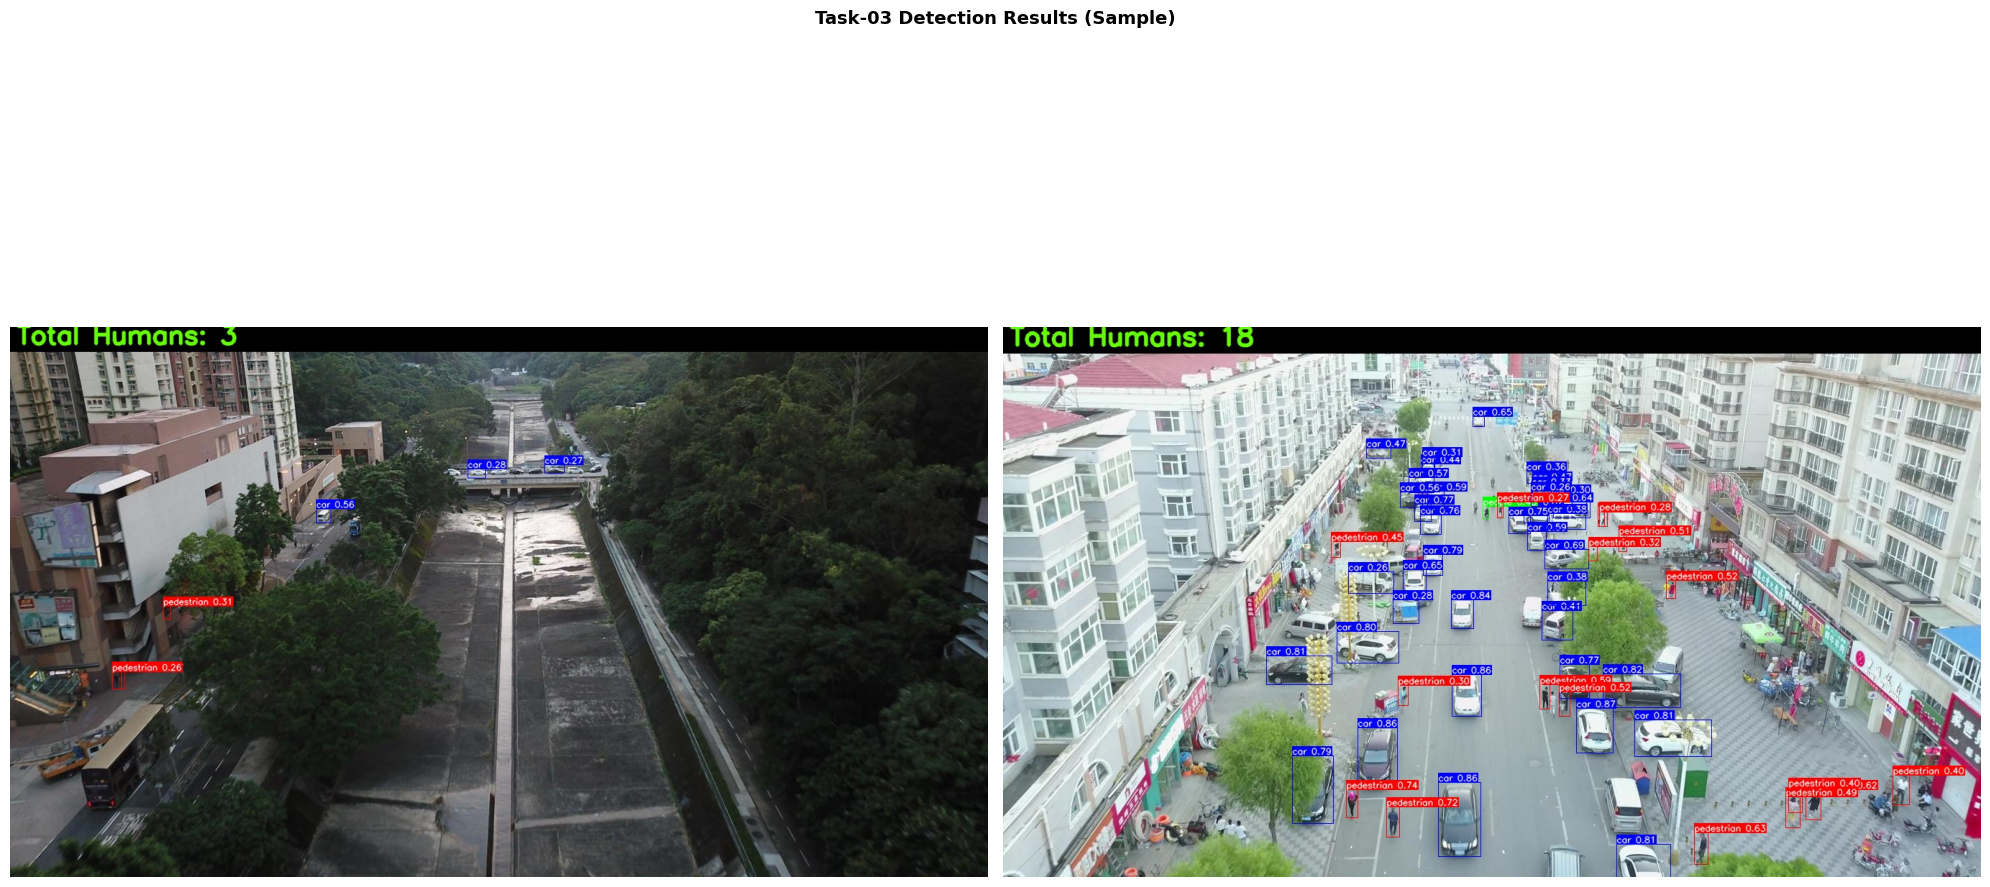

In [11]:
from ultralytics import YOLO
import cv2, os
import matplotlib.pyplot as plt
import random

WEIGHTS_PATH = r"D:\ANTS\runs\detect\outputs\train_filtered-2\weights\best.pt"
TEST_IMG_DIR = r"D:\ANTS\VisDrone_Dataset\VisDrone2019-DET-test-dev\images"
OUTPUT_DIR   = r"D:\ANTS\task03_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CLASS_NAMES = {
    0: "pedestrian",
    1: "people",
    2: "car"
}
COLORS_BGR = {
    0: (0, 0, 255),
    1: (0, 255, 0),
    2: (255, 0, 0),
}

model = YOLO(WEIGHTS_PATH)
print("Model loaded")

def detect_and_count(img_path, conf=0.25):
    img = cv2.imread(img_path)
    if img is None:
        return 0, None
    
    results = model(img_path, conf=conf, verbose=False)
    result  = results[0]
    human_count = 0
    
    if result.boxes is not None:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cls        = int(box.cls[0].item())
            conf_score = float(box.conf[0].item())
            
            if cls in [0, 1]:
                human_count += 1
            
            color = COLORS_BGR[cls]
            label = f"{CLASS_NAMES[cls]} {conf_score:.2f}"
            
            cv2.rectangle(img, (x1,y1), (x2,y2), color, 1)
            
            label_size = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)[0]
            cv2.rectangle(img,
                          (x1, y1-label_size[1]-4),
                          (x1+label_size[0], y1),
                          color, -1)
            cv2.putText(img, label, (x1, y1-2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4,
                        (255,255,255), 1, cv2.LINE_AA)
    
    cv2.rectangle(img, (0,0), (img.shape[1], 36), (0,0,0), -1)
    cv2.putText(img, f"Total Humans: {human_count}",
                (10,25), cv2.FONT_HERSHEY_SIMPLEX,
                1.2, (0,255,100), 3, cv2.LINE_AA)
    
    out_path = os.path.join(OUTPUT_DIR, "detected_" + os.path.basename(img_path))
    cv2.imwrite(out_path, img)
    return human_count, out_path


# ── Run on ALL test images ──
test_imgs = [f for f in sorted(os.listdir(TEST_IMG_DIR))
             if f.endswith('.jpg')]
# No [:10] slice — gets every single jpg in the test folder

print(f"Found {len(test_imgs)} test images. Running detection...\n")

total_humans_all_images = 0
processed = 0

for img_file in test_imgs:
    count, saved = detect_and_count(os.path.join(TEST_IMG_DIR, img_file))
    total_humans_all_images += count
    processed += 1
    
    # Print progress every 100 images so you know it's still running
    if processed % 100 == 0:
        print(f"  Processed {processed}/{len(test_imgs)} images...")

print(f"\n Detection complete!")
print(f"   Total images processed : {processed}")
print(f"   Total humans detected  : {total_humans_all_images}")
print(f"   Avg humans per image   : {total_humans_all_images/processed:.1f}")
print(f"   Results saved to       : {OUTPUT_DIR}")


# ── Show 3 sample results inside notebook ──
fig, axes = plt.subplots(1, 2, figsize=(20, 12))
fig.suptitle('Task-03 Detection Results (Sample)', fontsize=13, fontweight='bold')

sample_imgs = random.sample(test_imgs, 2)

for ax, img_file in zip(axes, sample_imgs):
    sample_path = os.path.join(OUTPUT_DIR, "detected_" + img_file)
    img = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.savefig(r"D:\ANTS\task03_sample.png", dpi=150, bbox_inches='tight')
plt.show()